<a href="https://www.kaggle.com/code/sonawanelalitsunil/soil-pollution-health-risks-ml-51?scriptVersionId=233961370" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/soil-pollution-and-associated-health-impacts/soil_pollution_diseases.csv


## Title: "Soil Pollution & Health Risks"

### Description: Explore how soil pollution affects human health, analyzing pollutant levels, environmental factors, and associated diseases.



## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/soil-pollution-and-associated-health-impacts/soil_pollution_diseases.csv')

In [3]:
df.head()

,Case_ID,Date_Reported,Region,Country,Pollutant_Type,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,...,Soil_Texture,Soil_Organic_Matter_%,Disease_Type,Disease_Severity,Health_Symptoms,Age_Group_Affected,Gender_Most_Affected,Mitigation_Measure,Case_Resolved,Follow_Up_Required
0,CASE_100000,2024-09-12,Africa,Pakistan,Lead,78.04,8.30,35.6,64.9,62.4,...,Sandy,1.98,Gastrointestinal Disease,Moderate,Breathing Difficulty,Adults,Male,Government Regulation,No,Yes
1,CASE_100001,2024-01-01,Africa,Germany,Lead,16.33,7.96,31.0,73.1,8.2,...,Silty,9.71,Cancer,Mild,Breathing Difficulty,Elderly,Both,Community Awareness,Yes,No
2,CASE_100002,2025-02-24,Europe,Germany,Lead,167.33,5.35,16.4,33.8,121.7,...,Clay,5.49,Gastrointestinal Disease,Severe,Nausea,Children,Both,Soil Remediation,Yes,No
3,CASE_100003,2024-09-24,Asia,USA,Lead,89.23,5.66,31.4,30.5,116.9,...,Silty,3.98,Neurological Disorder,Severe,Fatigue,Adults,Male,Community Awareness,Yes,No
4,CASE_100004,2023-05-24,Africa,India,Chromium,93.93,7.64,17.0,58.6,237.0,...,Loamy,0.94,Skin Disease,Moderate,Breathing Difficulty,Children,Female,Government Regulation,Yes,Yes


In [4]:
df.tail()

,Case_ID,Date_Reported,Region,Country,Pollutant_Type,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,...,Soil_Texture,Soil_Organic_Matter_%,Disease_Type,Disease_Severity,Health_Symptoms,Age_Group_Affected,Gender_Most_Affected,Mitigation_Measure,Case_Resolved,Follow_Up_Required
2995,CASE_102995,2024-04-08,Asia,Mexico,Mercury,14.27,7.06,12.3,75.0,215.6,...,Silty,2.39,Respiratory Issues,Severe,Abdominal Pain,Elderly,Both,Crop Rotation,Yes,Yes
2996,CASE_102996,2024-12-28,Asia,Australia,Pesticides,110.21,5.23,25.4,80.0,184.8,...,Clay,1.91,Neurological Disorder,Severe,Breathing Difficulty,Adults,Female,Government Regulation,Yes,No
2997,CASE_102997,2023-07-15,Europe,India,Chromium,146.15,5.25,35.8,56.0,181.5,...,Silty,8.59,Cancer,Mild,Fatigue,Children,Female,Government Regulation,No,No
2998,CASE_102998,2024-07-30,Asia,USA,Lead,143.18,4.63,20.4,85.3,7.3,...,Silty,5.68,Neurological Disorder,Mild,Abdominal Pain,Adults,Female,Soil Remediation,Yes,Yes
2999,CASE_102999,2024-09-04,North America,China,Cadmium,146.93,6.99,36.6,74.4,276.8,...,Silty,8.30,Respiratory Issues,Mild,Breathing Difficulty,Elderly,Both,Chemical Neutralization,No,No


In [5]:
df.isnull().sum()

Case_ID                            0
Date_Reported                      0
Region                             0
Country                            0
Pollutant_Type                     0
Pollutant_Concentration_mg_kg      0
Soil_pH                            0
Temperature_C                      0
Humidity_%                         0
Rainfall_mm                        0
Crop_Type                          0
Farming_Practice                   0
Nearby_Industry                  582
Water_Source_Type                  0
Soil_Texture                       0
Soil_Organic_Matter_%              0
Disease_Type                       0
Disease_Severity                   0
Health_Symptoms                    0
Age_Group_Affected                 0
Gender_Most_Affected               0
Mitigation_Measure                 0
Case_Resolved                      0
Follow_Up_Required                 0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.dtypes

Case_ID                           object
Date_Reported                     object
Region                            object
Country                           object
Pollutant_Type                    object
Pollutant_Concentration_mg_kg    float64
Soil_pH                          float64
Temperature_C                    float64
Humidity_%                       float64
Rainfall_mm                      float64
Crop_Type                         object
Farming_Practice                  object
Nearby_Industry                   object
Water_Source_Type                 object
Soil_Texture                      object
Soil_Organic_Matter_%            float64
Disease_Type                      object
Disease_Severity                  object
Health_Symptoms                   object
Age_Group_Affected                object
Gender_Most_Affected              object
Mitigation_Measure                object
Case_Resolved                     object
Follow_Up_Required                object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Case_ID                        3000 non-null   object 
 1   Date_Reported                  3000 non-null   object 
 2   Region                         3000 non-null   object 
 3   Country                        3000 non-null   object 
 4   Pollutant_Type                 3000 non-null   object 
 5   Pollutant_Concentration_mg_kg  3000 non-null   float64
 6   Soil_pH                        3000 non-null   float64
 7   Temperature_C                  3000 non-null   float64
 8   Humidity_%                     3000 non-null   float64
 9   Rainfall_mm                    3000 non-null   float64
 10  Crop_Type                      3000 non-null   object 
 11  Farming_Practice               3000 non-null   object 
 12  Nearby_Industry                2418 non-null   o

In [9]:
df.describe()

,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,Soil_Organic_Matter_%
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000
mean,102.745587,6.463747,27.225100,58.222867,200.31660,5.175093
std,55.907366,1.166305,10.084577,21.357711,115.27187,2.761633
min,5.030000,4.500000,10.000000,20.000000,0.00000,0.500000
25%,54.425000,5.457500,18.500000,39.900000,100.60000,2.760000
50%,104.085000,6.450000,27.000000,58.450000,199.00000,5.130000
75%,151.472500,7.490000,35.825000,76.800000,299.75000,7.550000
max,199.990000,8.500000,45.000000,95.000000,399.70000,10.000000


In [10]:
df.shape

(3000, 24)

In [11]:
df.columns

Index(['Case_ID', 'Date_Reported', 'Region', 'Country', 'Pollutant_Type',
       'Pollutant_Concentration_mg_kg', 'Soil_pH', 'Temperature_C',
       'Humidity_%', 'Rainfall_mm', 'Crop_Type', 'Farming_Practice',
       'Nearby_Industry', 'Water_Source_Type', 'Soil_Texture',
       'Soil_Organic_Matter_%', 'Disease_Type', 'Disease_Severity',
       'Health_Symptoms', 'Age_Group_Affected', 'Gender_Most_Affected',
       'Mitigation_Measure', 'Case_Resolved', 'Follow_Up_Required'],
      dtype='object')

## Data visualizations

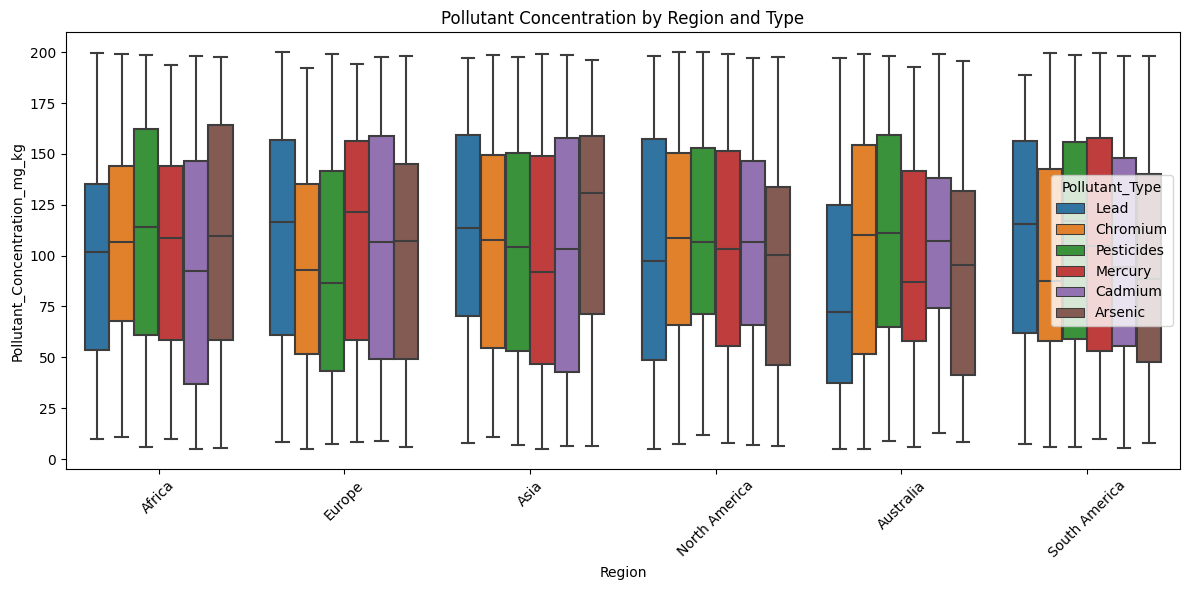

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Region', y='Pollutant_Concentration_mg_kg', hue='Pollutant_Type')
plt.xticks(rotation=45)
plt.title('Pollutant Concentration by Region and Type')
plt.tight_layout()
plt.show()

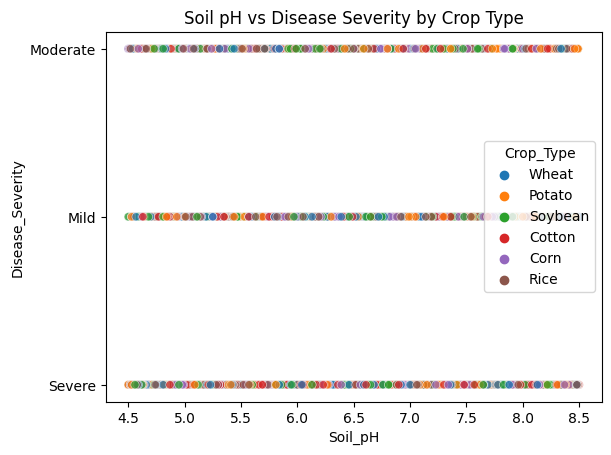

In [13]:
sns.scatterplot(data=df, x='Soil_pH', y='Disease_Severity', hue='Crop_Type', alpha=0.7)
plt.title('Soil pH vs Disease Severity by Crop Type')
plt.show()


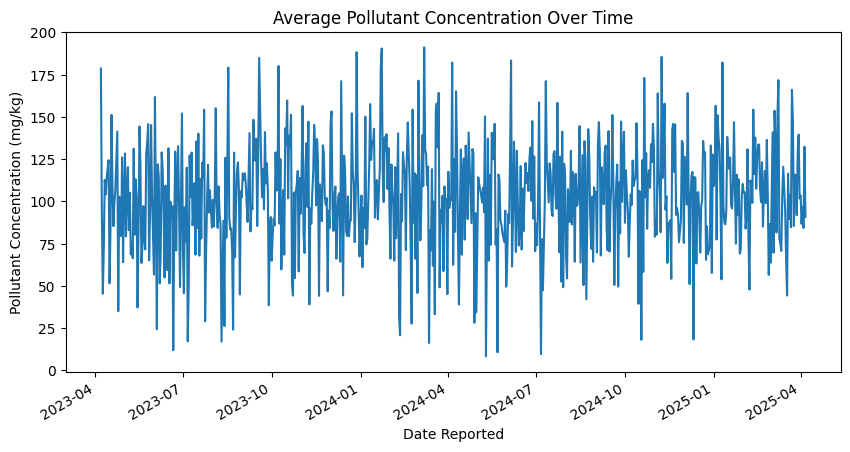

In [14]:
df['Date_Reported'] = pd.to_datetime(df['Date_Reported'])
pollution_trend = df.groupby('Date_Reported')['Pollutant_Concentration_mg_kg'].mean()

plt.figure(figsize=(10,5))
pollution_trend.plot()
plt.title('Average Pollutant Concentration Over Time')
plt.ylabel('Pollutant Concentration (mg/kg)')
plt.xlabel('Date Reported')
plt.show()


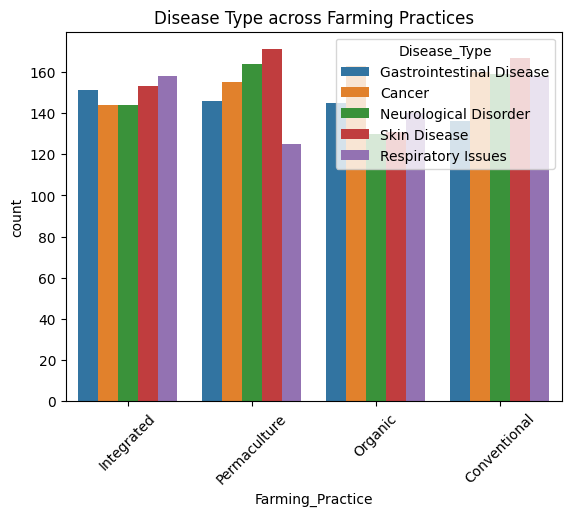

In [15]:
sns.countplot(data=df, x='Farming_Practice', hue='Disease_Type')
plt.xticks(rotation=45)
plt.title('Disease Type across Farming Practices')
plt.show()


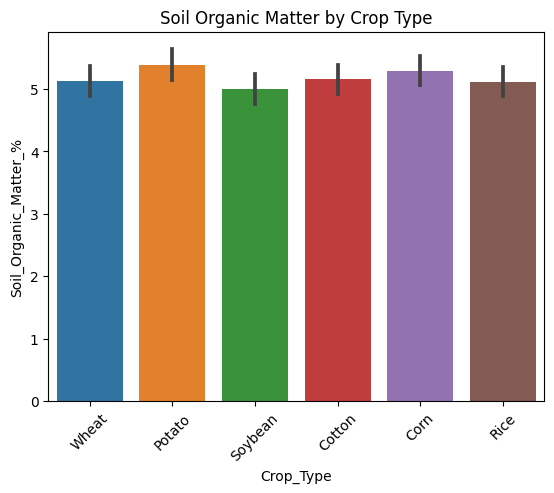

In [16]:
sns.barplot(data=df, x='Crop_Type', y='Soil_Organic_Matter_%')
plt.xticks(rotation=45)
plt.title('Soil Organic Matter by Crop Type')
plt.show()


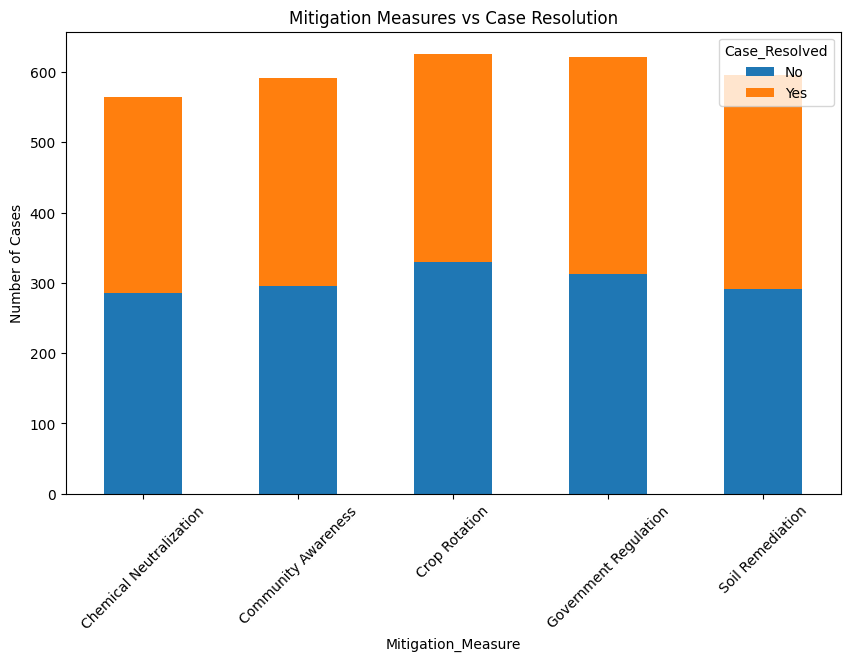

In [17]:
resolved_mitigation = df.groupby(['Mitigation_Measure', 'Case_Resolved']).size().unstack(fill_value=0)

resolved_mitigation.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Mitigation Measures vs Case Resolution')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.show()


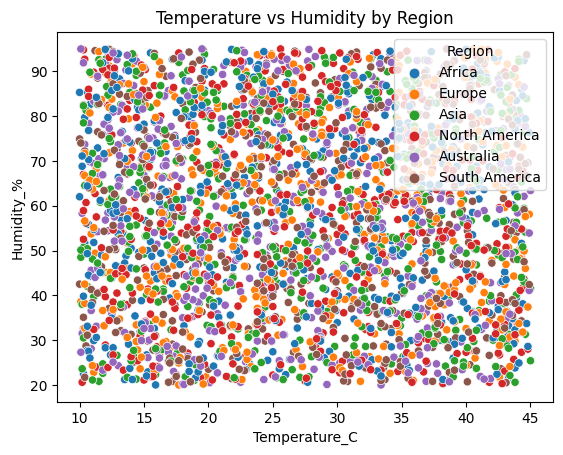

In [18]:
sns.scatterplot(data=df, x='Temperature_C', y='Humidity_%', hue='Region')
plt.title('Temperature vs Humidity by Region')
plt.show()


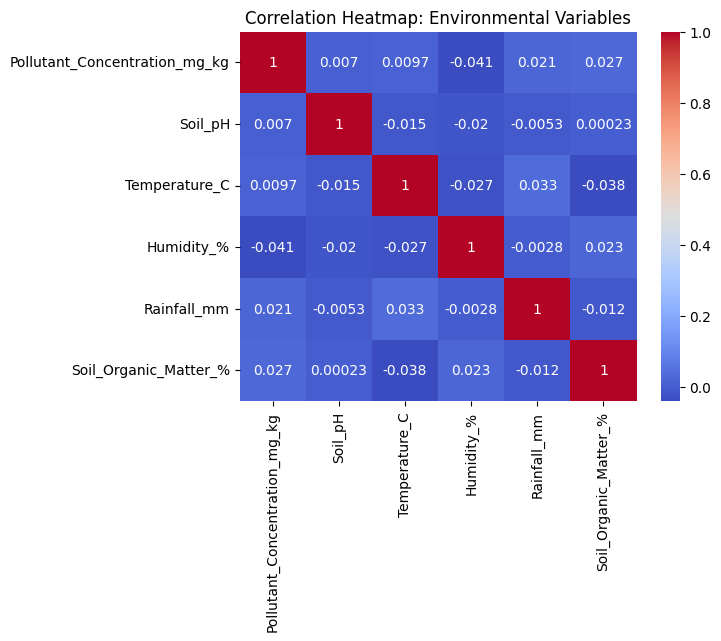

In [19]:
env_cols = ['Pollutant_Concentration_mg_kg', 'Soil_pH', 'Temperature_C', 'Humidity_%', 'Rainfall_mm', 'Soil_Organic_Matter_%']
sns.heatmap(df[env_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Environmental Variables')
plt.show()


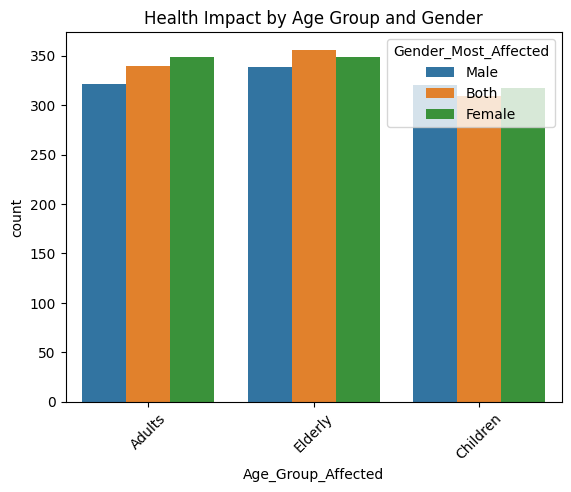

In [20]:
sns.countplot(data=df, x='Age_Group_Affected', hue='Gender_Most_Affected')
plt.title('Health Impact by Age Group and Gender')
plt.xticks(rotation=45)
plt.show()


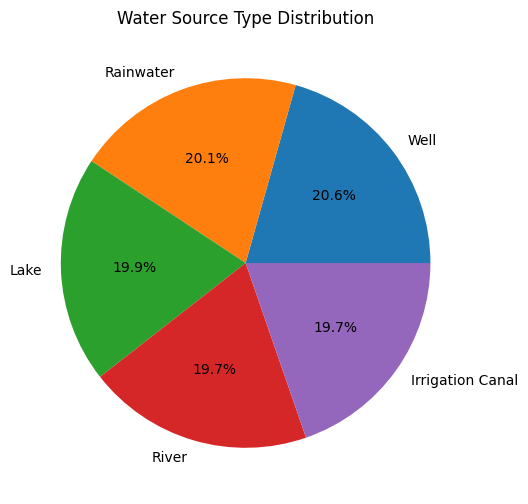

In [21]:
df['Water_Source_Type'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title('Water Source Type Distribution')
plt.ylabel('')
plt.show()


## Predictive modeling

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay, classification_report
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [23]:
# Target and features
target_column = 'Case_Resolved'
feature_cols = [col for col in df.columns if col != target_column]

if target_column in df.columns:
    X = df[feature_cols]
    y = df[target_column]

    # Label encode if target is categorical
    if y.dtype == 'object':
        y = LabelEncoder().fit_transform(y)


In [24]:
# Assuming your data is already prepared (X and y)
drop_cols = ['Case_ID', 'Date_Reported']  # Drop non-numeric columns
X = df.drop(columns=drop_cols + ['Case_Resolved'])
y = df['Case_Resolved']

# Optional: Convert categorical features to numeric (if any)
X = pd.get_dummies(X, drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

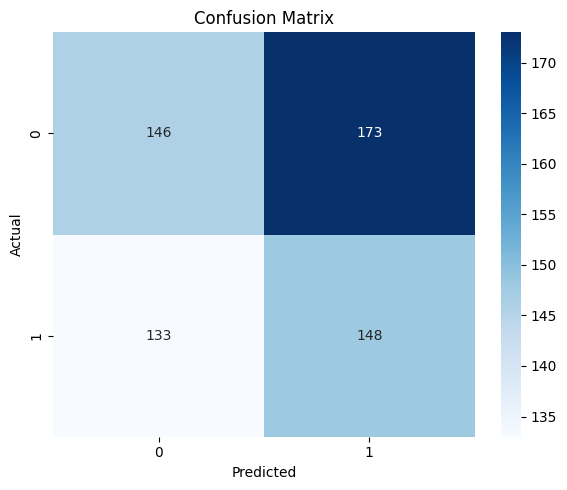

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

✅ Accuracy: 49.67%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.45      0.49       319
           1       0.47      0.54      0.50       281

    accuracy                           0.50       600
   macro avg       0.50      0.50      0.50       600
weighted avg       0.50      0.50      0.50       600



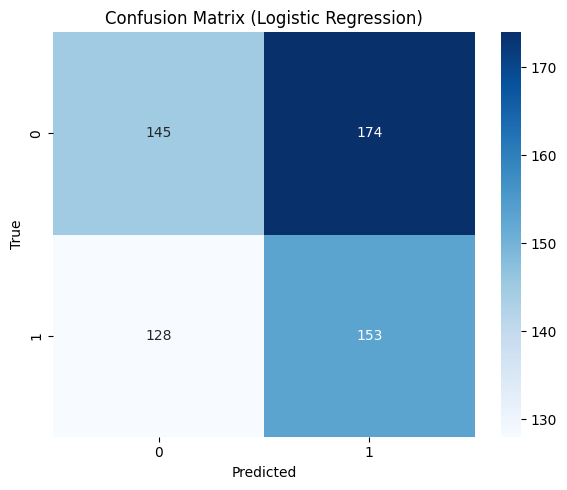

<Figure size 800x600 with 0 Axes>

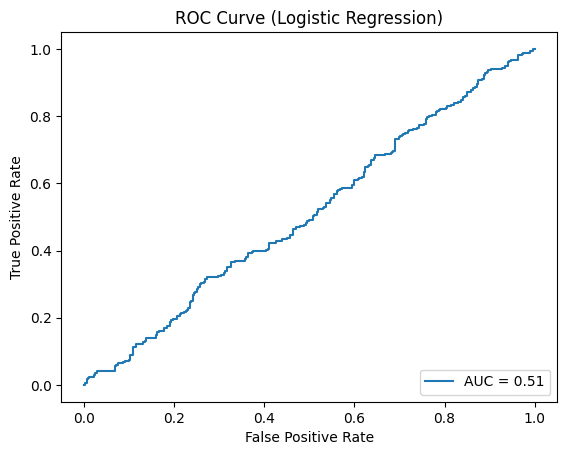

✅ Accuracy: 47.67%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.48      0.49       319
           1       0.45      0.48      0.46       281

    accuracy                           0.48       600
   macro avg       0.48      0.48      0.48       600
weighted avg       0.48      0.48      0.48       600



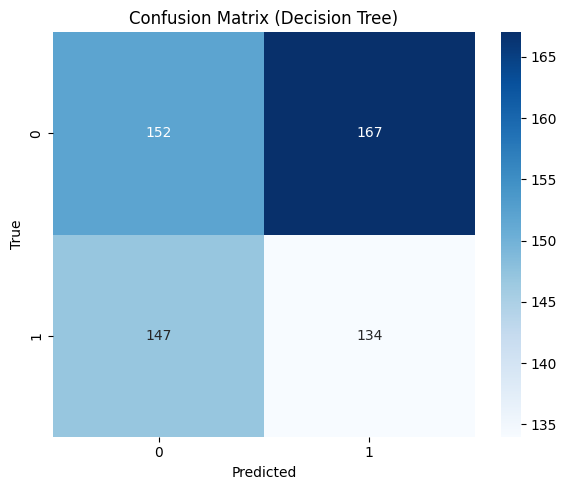

<Figure size 800x600 with 0 Axes>

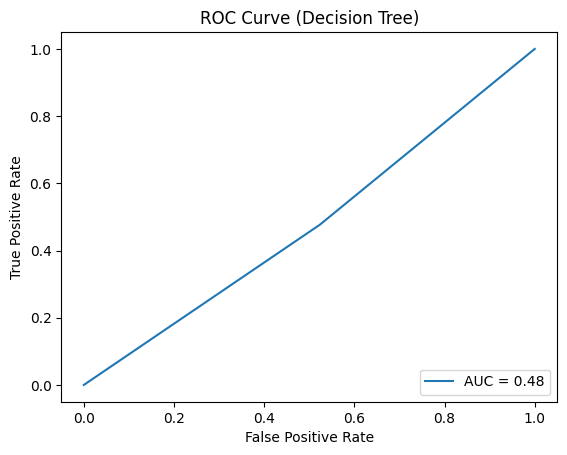

✅ Accuracy: 50.50%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.55      0.54       319
           1       0.47      0.45      0.46       281

    accuracy                           0.51       600
   macro avg       0.50      0.50      0.50       600
weighted avg       0.50      0.51      0.50       600



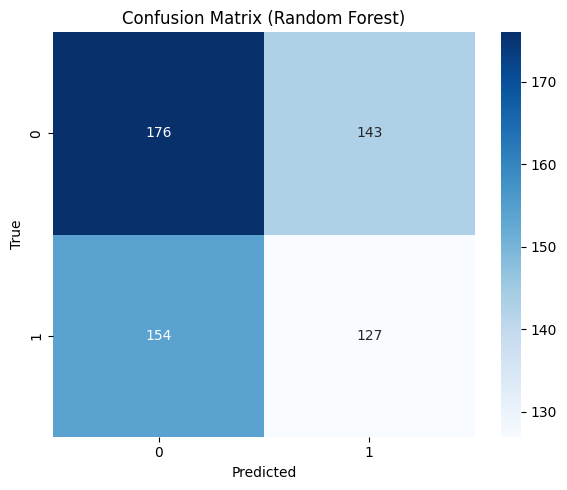

<Figure size 800x600 with 0 Axes>

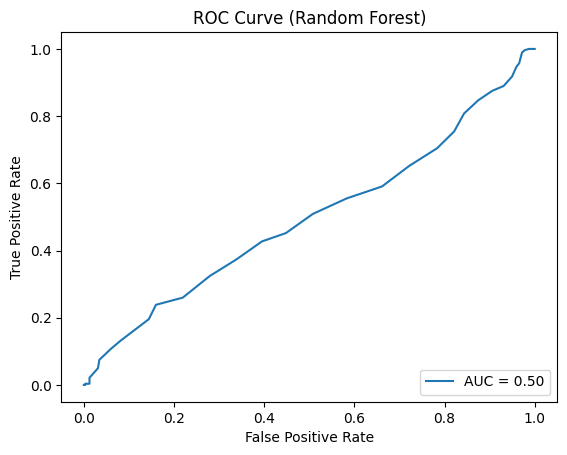

✅ Accuracy: 50.00%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.49      0.51       319
           1       0.47      0.51      0.49       281

    accuracy                           0.50       600
   macro avg       0.50      0.50      0.50       600
weighted avg       0.50      0.50      0.50       600



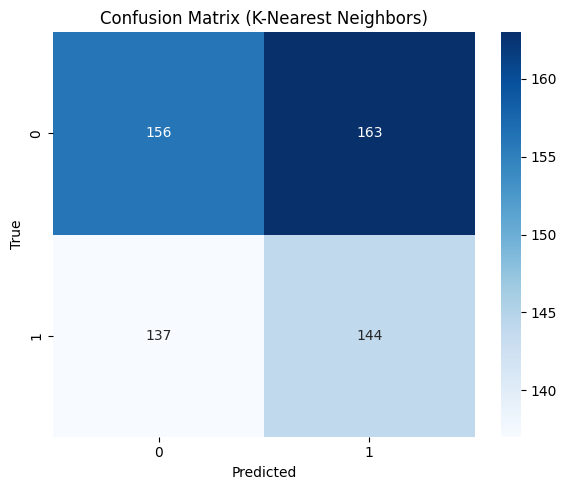

<Figure size 800x600 with 0 Axes>

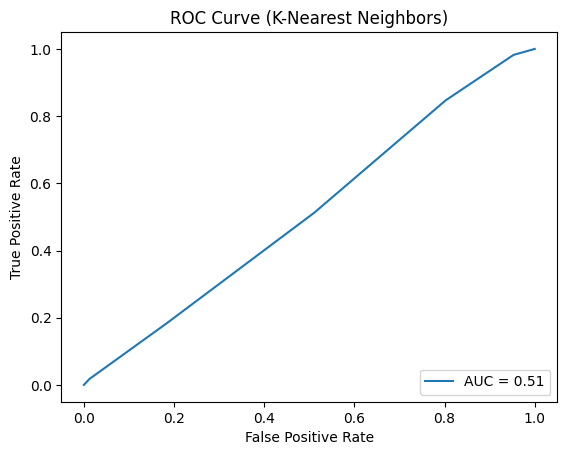

✅ Accuracy: 48.17%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.47      0.49       319
           1       0.45      0.49      0.47       281

    accuracy                           0.48       600
   macro avg       0.48      0.48      0.48       600
weighted avg       0.48      0.48      0.48       600



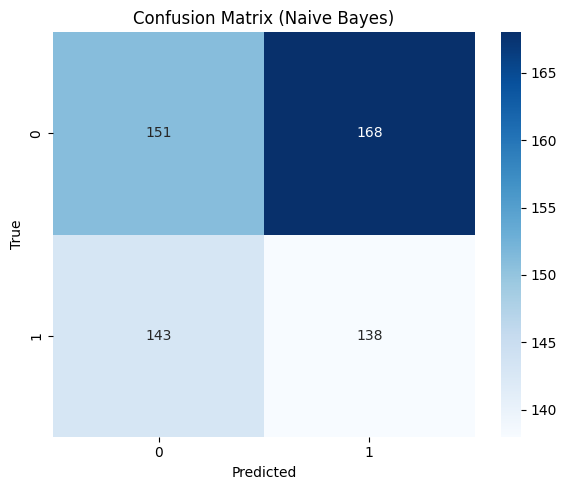

<Figure size 800x600 with 0 Axes>

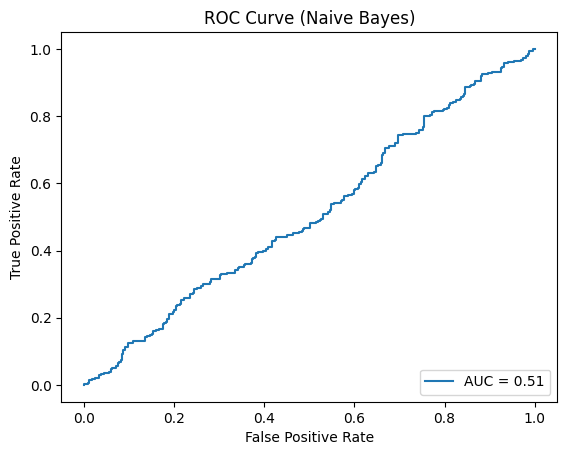

✅ Accuracy: 49.17%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.46      0.49       319
           1       0.46      0.52      0.49       281

    accuracy                           0.49       600
   macro avg       0.49      0.49      0.49       600
weighted avg       0.50      0.49      0.49       600



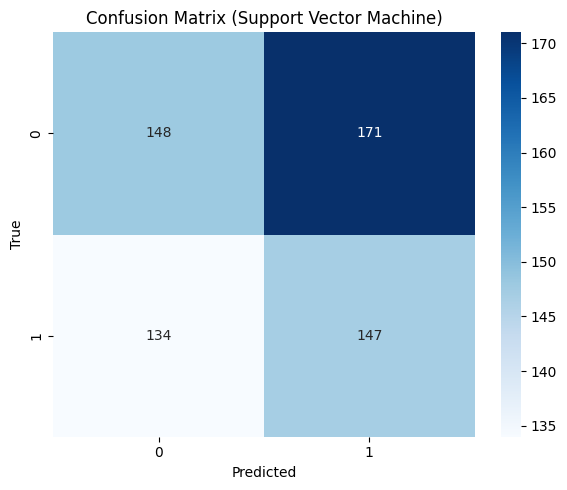

<Figure size 800x600 with 0 Axes>

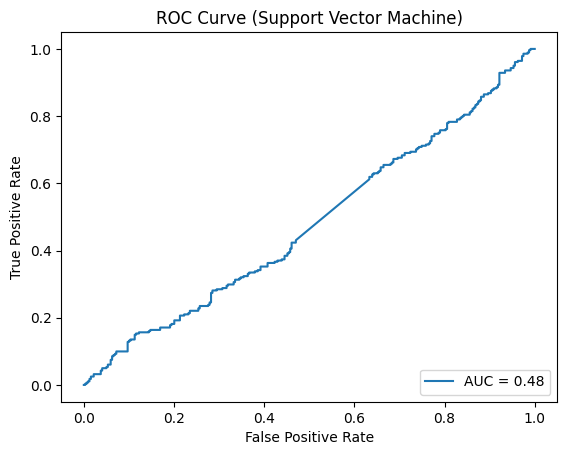

✅ Accuracy: 51.17%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       319
           1       0.48      0.51      0.49       281

    accuracy                           0.51       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.51      0.51      0.51       600



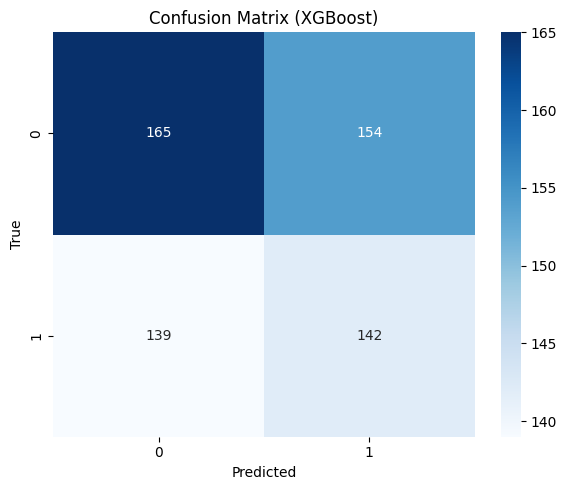

<Figure size 800x600 with 0 Axes>

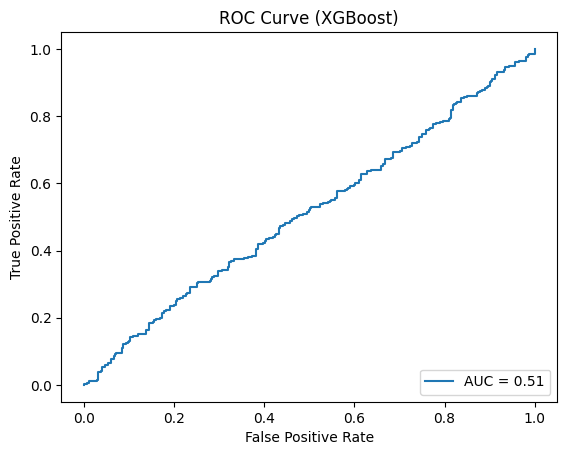

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(probability=True),  # Add probability=True for SVC to use predict_proba
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the labels to numeric values (0 and 1)
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Initialize the results list
results = []

# Now fit the model with encoded labels
for name, model in models.items():
    model.fit(X_train, y_train_encoded)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test_encoded, preds) * 100
    results.append((name, acc))
    print(f"✅ Accuracy: {acc:.2f}%")
    print("📊 Classification Report:")
    print(classification_report(y_test_encoded, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test_encoded, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
    plt.title(f'Confusion Matrix ({name})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    # ROC Curve and AUC
    if len(np.unique(y_test_encoded)) == 2:  # Binary Classification
        # Get predicted probabilities
        y_pred_prob = model.predict_proba(X_test)[:, 1]  # For binary classification, select the probability for class 1
        
        fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(8, 6))
        RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
        plt.title(f'ROC Curve ({name})')
        plt.show()

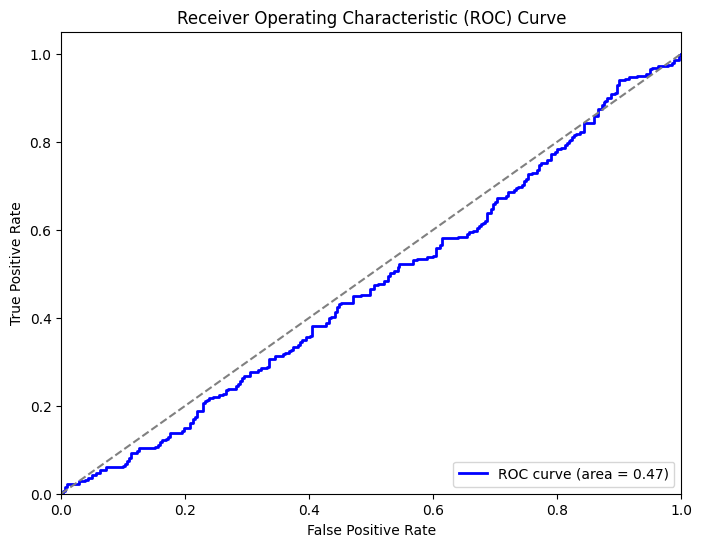

In [27]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the labels in y_test and y_pred_prob to numeric values (0 and 1)
y_test_encoded = label_encoder.fit_transform(y_test)  # Ensure y_test is encoded to 0 and 1
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]  # Get probabilities for the positive class

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [28]:
result_df = pd.DataFrame(results, columns=["Model", "Accuracy (%)"])
print("\n🎯 Final Model Accuracies:")
print(result_df.sort_values(by="Accuracy (%)", ascending=False))


🎯 Final Model Accuracies:
                    Model  Accuracy (%)
6                 XGBoost     51.166667
2           Random Forest     50.500000
3     K-Nearest Neighbors     50.000000
0     Logistic Regression     49.666667
5  Support Vector Machine     49.166667
4             Naive Bayes     48.166667
1           Decision Tree     47.666667


## Thank you..pls upvote